Anaconda ambiente YouTube no linux

Na Classificação prevemos classes e na regressão prevemos números

# Projeto 8: Regressão carros usados

## Etapa 1: Importação das bibliotecas

In [4]:
import pandas as pd
import torch
import numpy as np
import seaborn as sns
from torch import nn, optim # otimizador
import torch.nn.functional as F # funcional
torch.__version__

'2.8.0+cu126'

## Etapa 2: Base de dados

Codificação para a reprodutibilidade, para sempre termos os mesmos resultados.

In [5]:
np.random.seed(123)
torch.manual_seed(123)

In [6]:
base = pd.read_csv('autos.csv', encoding = 'ISO-8859-1')

In [7]:
base.tail()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
11399,2016-03-28 20:25:20,Volkswagen_Golf_CL,privat,Angebot,1199,control,limousine,1991,manuell,54,golf,90000,12,benzin,volkswagen,nein,2016-03-28 00:00:00,0,65719,2016-04-07 06:15:31
11400,2016-03-27 21:36:56,Suzuki_Jimny,privat,Angebot,5900,test,suv,2002,manuell,82,jimny,60000,2,benzin,suzuki,nein,2016-03-27 00:00:00,0,79410,2016-03-29 13:44:32
11401,2016-03-25 02:36:16,Bmw_e46_320i,privat,Angebot,0,control,limousine,1999,manuell,150,3er,150000,5,benzin,bmw,NaN,2016-03-25 00:00:00,0,70499,2016-03-26 18:15:19
11402,2016-03-24 15:38:53,Volkswagen_Passat_Variant_1.9_TDI_Comfortline_...,privat,Angebot,1999,test,kombi,2003,manuell,101,passat,150000,5,diesel,volkswagen,nein,2016-03-24 00:00:00,0,52428,2016-03-24 15:38:53
11403,2016-04-04 13:46:44,Mercedes_Benz_CLK_Coupe_500,privat,Angebot,11400,control,coupe,2003,automatik,306,clk,125000,5,benzin,mercedes_benz,nein,2016-04-04 00:00:00,0,73072,2016-04-06 15:


In [8]:
base.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


# utilizar algum desses atributos para fazer a previsão dos preços

In [9]:
base.columns

Index(['dateCrawled', 'name', 'seller', 'offerType', 'price', 'abtest',
       'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model',
       'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage', 'dateCreated', 'nrOfPictures', 'postalCode',
       'lastSeen'],
      dtype='object')

In [10]:
# apagar alguns atributos que não são muito relevantes.


# datas no momento não nos interessa
#'dateCrawled',
#'dateCreated',
#'nrOfPictures', número de fotos não interfere
#'postalCode' no momento o cep não importa
#  'lastSeen' data da última visualização no site.


In [11]:
# faremos a limpeza dos dados,
# manterá as colunas:

# 'name', 'seller', 'offerType', 'price', 'abtest', 'vehicleType', 'yearOfRegistration'
# 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration',
#  'fuelType', 'brand',
#  'notRepairedDamage', 'dateCreated',


In [12]:
base.shape

(11404, 20)

In [13]:
print(f'Quantidades de registros na nossa base de dados auto.csv são de {base.shape[0]} e com {base.shape[1]} colunas ou atributos.')

Quantidades de registros na nossa base de dados auto.csv são de 11404 e com 20 colunas ou atributos.


In [14]:
# axis =1 apaga a coluna
# axis = 0 apaga a linha

### Eliminar 5 colunas

In [15]:
base = base.drop('dateCrawled', axis = 1)
base = base.drop('dateCreated', axis = 1)
base = base.drop('nrOfPictures', axis = 1)
base = base.drop('postalCode', axis = 1)
base = base.drop('lastSeen', axis = 1)

In [16]:
base.shape

(11404, 15)

In [17]:
print(f'Quantidades de registros na nossa base de dados auto.csv são de {base.shape[0]} e com nova quantidade de colunas ou atributos:{base.shape[1]}.')

Quantidades de registros na nossa base de dados auto.csv são de 11404 e com nova quantidade de colunas ou atributos:15.


In [18]:
base.head()

,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN
1,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja
2,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN
3,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein
4,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein


In [19]:
# análise dos nomes dos carros
base['name'].value_counts()

,count
name,
Ford_Fiesta,26
BMW_318i,21
Renault_Twingo,20
BMW_316i,19
BMW_320i,16
...,...
Renault_Kangoo_Happy_Family,1
Mercedes_Benz_CLK_Cabrio_320_CDI_7G_AMG_Grand_Edition,1
Vw_Polo_1_4_TÜV_3/2018_comfortline,1


In [20]:
base['name'].unique()

array(['Golf_3_1.6', 'A5_Sportback_2.7_Tdi',
       'Jeep_Grand_Cherokee_"Overland"', ...,
       'BMW_E36_320i_3er_6_Zylinder_Exclusiv_Edition__Leder__Klima',
       'Bmw_e46_320i', 'Mercedes_Benz_CLK_Coupe_500'], dtype=object)

In [21]:
len(base['name'].unique()) # quantidade de nomes dos carros.

10024

In [22]:
# name será substituido por model:
base['model'].unique()

array(['golf', nan, 'grand', 'fabia', '3er', '2_reihe', 'andere', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'c4', 'civic', 'transporter',
       'punto', 'e_klasse', 'clio', 'kadett', 'kangoo', 'corsa', 'one',
       'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8', 'jetta',
       'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156', 'escort',
       'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia', 'combo',
       'focus', 'tt', 'a6', 'jazz', 'omega', 'slk', '7er', '80', '147',
       'glk', '100', 'z_reihe', 'sportage', 'sorento', 'v40', 'ibiza',
       'mustang', 'eos', 'touran', 'getz', 'a3', 'almera', 'megane',
       'lupo', 'r19', 'zafira', 'caddy', 'mondeo', 'cordoba', 'colt',
       'impreza', 'vectra', 'berlingo', 'm_klasse', 'tiguan', 'i_reihe',
       'espace', 'sharan', '6_reihe', 'panda', 'up', 'seicento', 'ceed',
       '5_reihe', 'yeti', 'octavia', 'mii', 'rx_reihe', '

In [23]:
base['model'].value_counts()

,count
model,
golf,861
andere,793
3er,660
polo,406
corsa,366
...,...
move,1
9000,1
v60,1


In [24]:
len(base['model'].unique()) # quantidade de modelos dos carros.

239

In [25]:
# apagaremos a coluna name
base = base.drop('name', axis = 1)

In [26]:
# vendedor
base['seller'].value_counts()

,count
seller,
privat,11404


privat - privado

gewerblich  - acessível

In [27]:
# apagaremos a coluna seller, pois não faz diferença, a maioria é para o privado.
base = base.drop('seller', axis = 1)

In [28]:
base['offerType'].value_counts() # está bem desbalanceado, igual o seller, mais para um do que para outro

,count
offerType,
Angebot,11404


In [29]:
base = base.drop('offerType', axis = 1)

In [30]:
base.head()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN
1,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja
2,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN
3,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein
4,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein


In [31]:
print(f'Quantidades de registros na nossa base de dados auto.csv são de {base.shape[0]} e com nova quantidade de colunas ou atributos:{base.shape[1]}.')

Quantidades de registros na nossa base de dados auto.csv são de 11404 e com nova quantidade de colunas ou atributos:12.


## Verificar se tem um preço inconsistente

In [32]:
# ver se tem carros como preço abaixo ou igual aos 10 euros
i1 = base.loc[base.price <= 10]

In [33]:
i1.shape

(366, 12)

In [34]:
base = base[base.price > 10]

In [35]:
base.shape

(11038, 12)

In [36]:
base.shape

(11038, 12)

In [37]:
import plotly.express as px
import plotly.graph_objects as go

#grafico = px.scatter(y = base['price'], title='<b>Amostra dos dados preços de carros.</b>')

#grafico.update_layout(
#    xaxis_title_text='X',
#    yaxis_title_text='Price',
    # padrão o título
#    title_font_size=20,  # Define o tamanho da fonte do título
#    title_font_family='Arial Black', # Uma fonte mais grossa
#    title_x=0.5 # Centraliza o título no gráfico
#)

#grafico.show()
#grafico.write_html("grafico1.html")

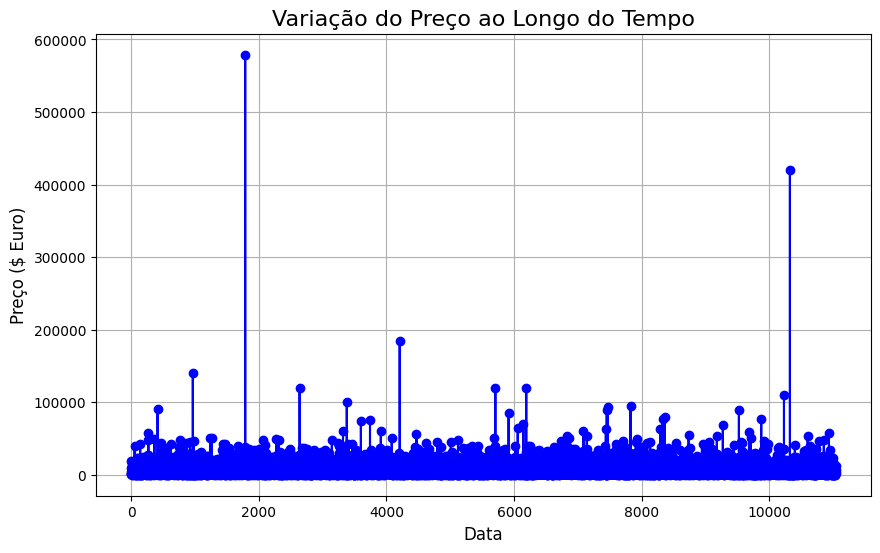

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

df = base.reset_index(drop=True)
# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot( df['price'], marker='o', linestyle='-', color='b')

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

In [39]:
# outlier

i2 = base.loc[base.price > 350000]
i2.shape

(2, 12)

In [40]:
# retirar os outliers
base = base.loc[base.price < 350000]

In [41]:
base.shape

(11036, 12)

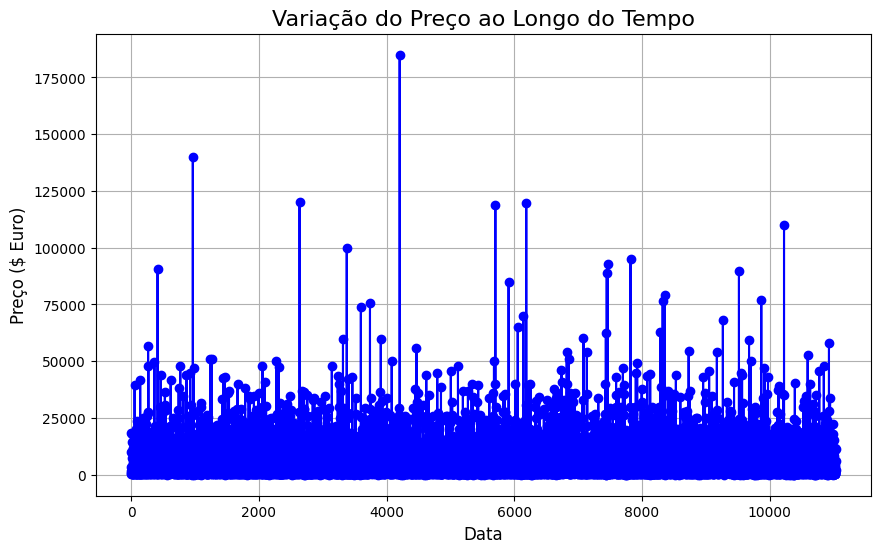

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

df = base.reset_index(drop=True)
# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot( df['price'], marker='o', linestyle='-', color='b')

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

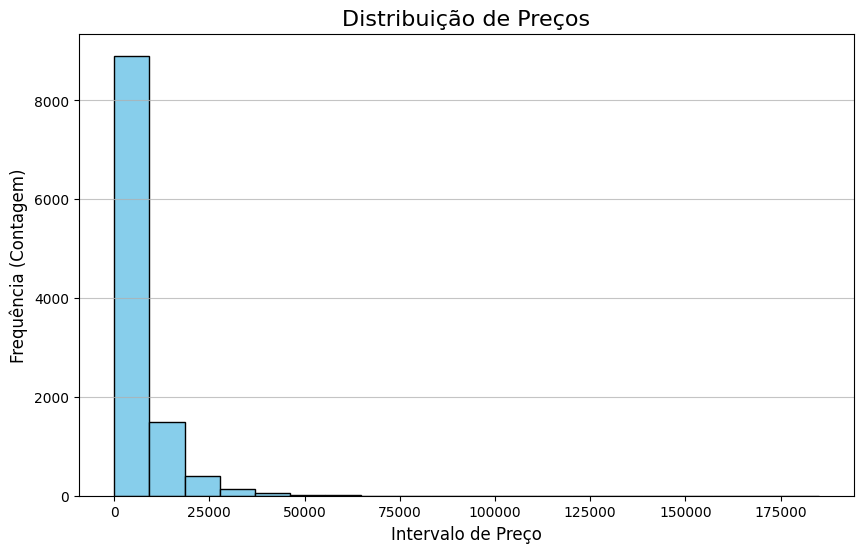

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar os dados de exemplo
# Gerando 100 preços aleatórios para o exemplo
#prices = np.random.normal(loc=150, scale=20, size=500)

# 2. Plotar o histograma
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=20, color='skyblue', edgecolor='black')

# 3. Adicionar títulos e rótulos
plt.title('Distribuição de Preços', fontsize=16)
plt.xlabel('Intervalo de Preço', fontsize=12)
plt.ylabel('Frequência (Contagem)', fontsize=12)
plt.grid(axis='y', alpha=0.75) # Adiciona uma grade no eixo Y
plt.show()

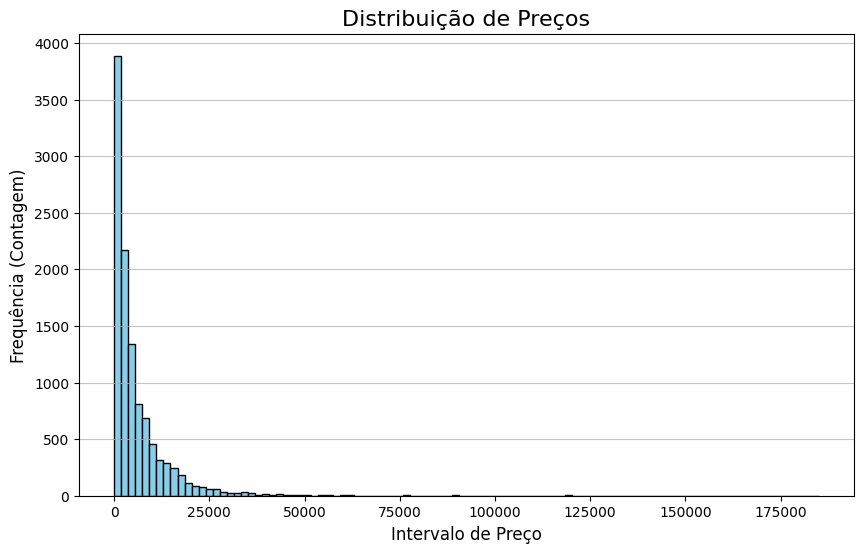

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar os dados de exemplo
# Gerando 100 preços aleatórios para o exemplo
#prices = np.random.normal(loc=150, scale=20, size=500)

# 2. Plotar o histograma
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=100, color='skyblue', edgecolor='black')

# 3. Adicionar títulos e rótulos
plt.title('Distribuição de Preços', fontsize=16)
plt.xlabel('Intervalo de Preço', fontsize=12)
plt.ylabel('Frequência (Contagem)', fontsize=12)
plt.grid(axis='y', alpha=0.75) # Adiciona uma grade no eixo Y
plt.show()

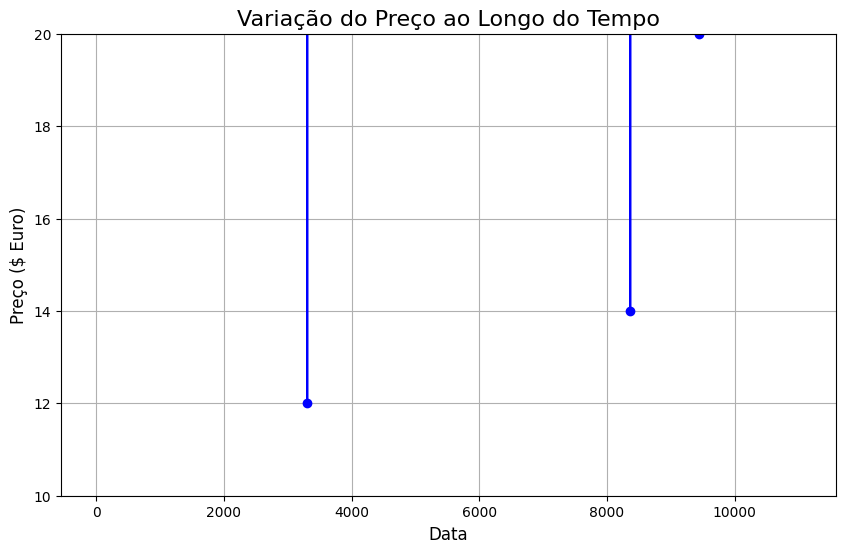

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


df = base.reset_index(drop=True)

# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot(df['price'], marker='o', linestyle='-', color='b')

# --- Adicionar esta linha para definir os limites do eixo Y ---
plt.ylim(10, 20)

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

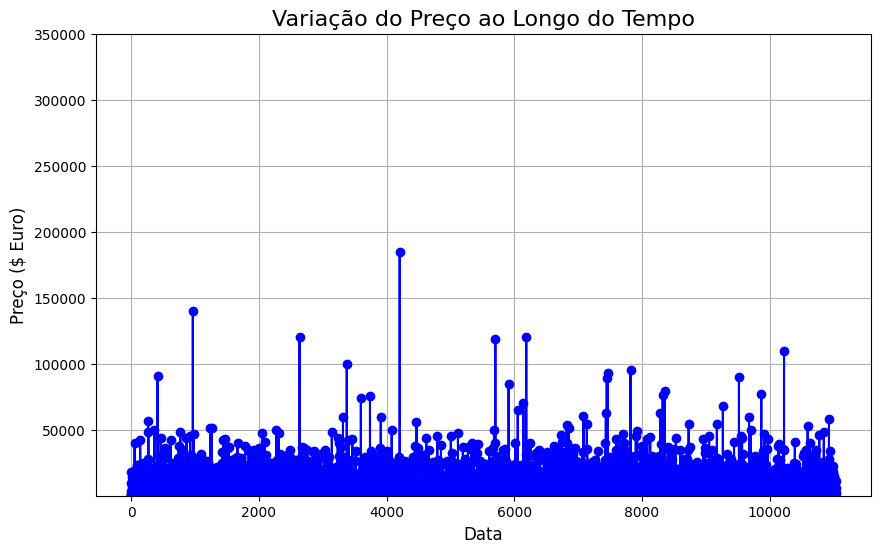

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# 2. Plotar o gráfico de linha
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
plt.plot(df['price'], marker='o', linestyle='-', color='b')

# --- Adicionar esta linha para definir os limites do eixo Y ---
plt.ylim(10, 350000)

# 3. Adicionar títulos e rótulos
plt.title('Variação do Preço ao Longo do Tempo', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço ($ Euro)', fontsize=12)
plt.grid(True) # Adiciona uma grade para facilitar a leitura
plt.show()

## tratamentos dos valores nulos

<Axes: >

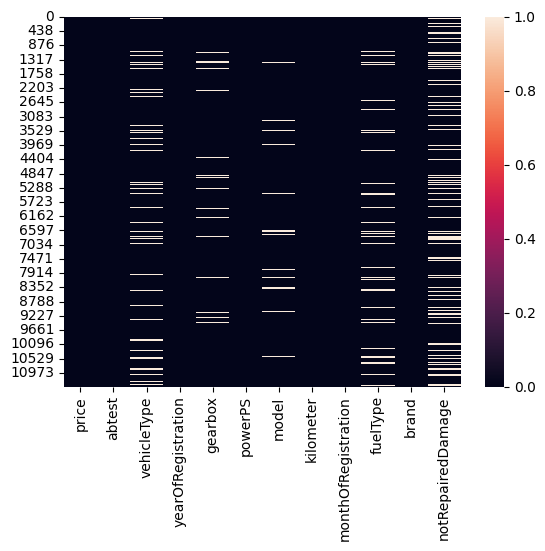

In [47]:
# verificar com o mapa de calores os dados nulos
sns.heatmap(base.isnull())

In [48]:
base.isnull().sum()

,0
price,0
abtest,0
vehicleType,1114
yearOfRegistration,0
gearbox,531
powerPS,0
model,533
kilometer,0
monthOfRegistration,0
fuelType,943


X atributos

y - valores dos registros

In [49]:
# valores nulos nas figuras estão em branco. Branco nulos nas posições.

### O que tem mais valores nulos é a coluna 'notRepairedDamage'.

## Analisar o tipo do veículo

##  vehicleType

In [50]:
base.loc[pd.isnull(base['vehicleType'])].tail(20) # verificar os valores nulos

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
11131,900,test,NaN,2017,manuell,115,80,150000,0,NaN,audi,NaN
11163,1400,test,NaN,2000,manuell,0,a_klasse,100000,3,benzin,mercedes_benz,NaN
11164,1890,control,NaN,2017,NaN,0,2_reihe,90000,6,NaN,peugeot,nein
11176,13990,control,NaN,2013,manuell,135,NaN,40000,1,benzin,hyundai,nein
11177,2250,test,NaN,2016,manuell,115,civic,80000,12,benzin,honda,nein
11205,7999,control,NaN,2006,automatik,218,5er,150000,6,benzin,bmw,NaN
11213,18000,control,NaN,2018,automatik,0,andere,100000,3,benzin,jaguar,NaN
11226,5800,test,NaN,2018,manuell,0,NaN,100000,8,benzin,mazda,NaN
11229,1400,test,NaN,2018,manuell,75,2_reihe,150000,9,benzin,peugeot,nein
11230,150,test,NaN,2016,manuell,0,astra,150000,8,NaN,opel,nein


In [51]:
len(base.loc[pd.isnull(base['vehicleType'])])

1114

In [52]:
base['vehicleType'].value_counts() # limousine é o veículo que mais aparece

,count
vehicleType,
limousine,2865
kleinwagen,2348
kombi,2015
bus,895
cabrio,696
coupe,570
suv,435
andere,98


In [53]:
base['vehicleType'].unique()

array([nan, 'coupe', 'suv', 'kleinwagen', 'limousine', 'cabrio', 'bus',
       'kombi', 'andere'], dtype=object)

apagar o NaN ou substituir os valores da coluna vehicleType

## gearbox

In [54]:
len(base.loc[pd.isnull(base['gearbox'])])

531

In [55]:
base.loc[pd.isnull(base['gearbox'])].tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
11247,700,control,kleinwagen,2002,NaN,60,punto,150000,7,benzin,fiat,ja
11253,100,test,NaN,2000,NaN,0,andere,80000,0,NaN,ford,NaN
11294,1000,test,kleinwagen,2000,NaN,0,fiesta,150000,11,benzin,ford,NaN
11315,590,control,limousine,1999,NaN,125,a_klasse,150000,7,lpg,mercedes_benz,nein
11384,120,control,NaN,2000,NaN,0,fiesta,150000,0,NaN,ford,ja


In [56]:
base['gearbox'].unique()

array(['manuell', 'automatik', nan], dtype=object)

In [57]:
base['gearbox'].value_counts() # manuell

,count
gearbox,
manuell,8224
automatik,2281


## model

In [58]:
len(base.loc[pd.isnull(base['model'])])

533

In [59]:
base.loc[pd.isnull(base['model'])].tail(20)

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
10972,500,test,NaN,2016,manuell,0,NaN,150000,0,diesel,peugeot,ja
10994,6999,control,limousine,2005,NaN,0,NaN,150000,0,NaN,bmw,NaN
11009,6800,test,coupe,2004,automatik,200,NaN,150000,12,benzin,audi,nein
11031,8200,control,limousine,2004,manuell,192,NaN,150000,10,benzin,bmw,NaN
11077,34980,test,suv,2011,automatik,420,NaN,150000,8,lpg,sonstige_autos,nein
11114,3750,test,limousine,1975,manuell,0,NaN,70000,3,benzin,renault,NaN
11127,620,test,NaN,2016,manuell,45,NaN,150000,3,benzin,opel,NaN
11130,2300,control,limousine,2002,automatik,0,NaN,150000,3,lpg,opel,nein
11143,2990,test,limousine,1961,manuell,0,NaN,5000,4,benzin,sonstige_autos,ja
11173,600,test,limousine,1998,manuell,165,NaN,150000,3,NaN,audi,NaN


In [60]:
base['model'].unique()

array(['golf', nan, 'grand', 'fabia', '3er', '2_reihe', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'andere', 'c4', 'civic',
       'transporter', 'punto', 'e_klasse', 'clio', 'kadett', 'kangoo',
       'one', 'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8',
       'jetta', 'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156',
       'escort', 'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia',
       'combo', 'focus', 'tt', 'corsa', 'a6', 'jazz', 'omega', 'slk',
       '7er', '80', '147', 'glk', '100', 'z_reihe', 'sportage', 'sorento',
       'v40', 'ibiza', 'mustang', 'eos', 'touran', 'getz', 'a3', 'almera',
       'megane', 'lupo', 'r19', 'zafira', 'caddy', 'mondeo', 'cordoba',
       'colt', 'impreza', 'vectra', 'berlingo', 'm_klasse', 'tiguan',
       'i_reihe', 'espace', 'sharan', '6_reihe', 'panda', 'up',
       'seicento', 'ceed', '5_reihe', 'yeti', 'octavia', 'mii',
       'rx_re

In [61]:
base['model'].value_counts() # golf

,count
model,
golf,832
andere,763
3er,637
polo,390
corsa,357
...,...
move,1
9000,1
v60,1


## fuelType

In [62]:
len(base.loc[pd.isnull(base['fuelType'])])

943

In [63]:
base.loc[pd.isnull(base['fuelType'])].tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
11343,4700,test,NaN,2017,manuell,90,galaxy,150000,6,NaN,ford,nein
11355,150,test,kleinwagen,1998,automatik,54,swift,125000,2,NaN,suzuki,nein
11372,2600,test,kombi,2002,manuell,150,3er,150000,0,NaN,bmw,NaN
11384,120,control,NaN,2000,NaN,0,fiesta,150000,0,NaN,ford,ja
11392,1750,control,kleinwagen,2003,manuell,54,polo,125000,11,NaN,volkswagen,nein


In [64]:
base['fuelType'].value_counts() # benzin

,count
fuelType,
benzin,6616
diesel,3312
lpg,138
cng,14
hybrid,8
andere,4
elektro,1


In [65]:
base['fuelType'].unique()

array(['benzin', 'diesel', nan, 'lpg', 'andere', 'hybrid', 'cng',
       'elektro'], dtype=object)

# último atributo  notRepairedDamage

In [66]:
base.loc[pd.isnull(base['notRepairedDamage'])].tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
11372,2600,test,kombi,2002,manuell,150,3er,150000,0,NaN,bmw,NaN
11380,220,test,kombi,2000,manuell,0,andere,150000,5,benzin,fiat,NaN
11381,2700,control,kleinwagen,2004,manuell,54,polo,150000,8,benzin,volkswagen,NaN
11388,190,test,kleinwagen,1999,manuell,45,corsa,125000,0,benzin,opel,NaN
11393,850,test,kleinwagen,1999,manuell,60,arosa,150000,5,diesel,seat,NaN


In [67]:
len(base.loc[pd.isnull(base['notRepairedDamage'])])

2020

In [68]:
base['notRepairedDamage'].value_counts() # nein

,count
notRepairedDamage,
nein,7940
ja,1076


nein => não

ja  => sim


In [69]:
base['notRepairedDamage'].unique()


array([nan, 'ja', 'nein'], dtype=object)

In [70]:
base.loc[pd.isnull(base['price'])]

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage


## Valores no formato do dicionário para preencher os dados nulos

In [71]:
valores = {'vehicleType': 'limousine', 'gearbox': 'manuell',
           'model': 'golf', 'fuelType': 'benzin',
           'notRepairedDamage': 'nein'}
# colunas: valores que mais aparecem

In [72]:
base = base.fillna(value = valores)

In [73]:
base.tail()

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
11398,1750,control,limousine,1996,manuell,150,3er,150000,10,benzin,bmw,nein
11399,1199,control,limousine,1991,manuell,54,golf,90000,12,benzin,volkswagen,nein
11400,5900,test,suv,2002,manuell,82,jimny,60000,2,benzin,suzuki,nein
11402,1999,test,kombi,2003,manuell,101,passat,150000,5,diesel,volkswagen,nein
11403,11400,control,coupe,2003,automatik,306,clk,125000,5,benzin,mercedes_benz,nein


In [74]:
base.isnull().sum()

,0
price,0
abtest,0
vehicleType,0
yearOfRegistration,0
gearbox,0
powerPS,0
model,0
kilometer,0
monthOfRegistration,0
fuelType,0


In [75]:
# fazer testes
base.loc[pd.isnull(base['notRepairedDamage'])]

,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage


## Terceiro tratamento dos dados

# Pré processamento adicionais

In [76]:
# 0 é o nosso objetivo preço

In [77]:
base.columns[1:13]

Index(['abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS',
       'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand',
       'notRepairedDamage'],
      dtype='object')

In [78]:
 base.columns[0]

'price'

In [79]:
base.shape

(11036, 12)

In [80]:
previsores = base.iloc[:, 1:13].values
preco_real = base.iloc[:, 0].values

In [81]:
previsores.shape

(11036, 11)

In [82]:
preco_real.shape

(11036,)

# Transformar os atributos categoricos em númericos

## ideia para usar o OneHotEncoder

In [83]:
# temos que ter cuidado para o tipo

# fazer a representação única
# gol  1 0 0
# pali 0 1 0
# uno  0 0 1


In [84]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# 0 0 0
# 0 1 0
# 0 0 1

In [85]:
atributos = base.iloc[:, 1:13].tail(2).reset_index(drop=True)
atributos

,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,test,kombi,2003,manuell,101,passat,150000,5,diesel,volkswagen,nein
1,control,coupe,2003,automatik,306,clk,125000,5,benzin,mercedes_benz,nein


In [86]:
len(list(atributos.columns))

11

In [87]:
print(list(atributos.columns))


['abtest', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'model', 'kilometer', 'monthOfRegistration', 'fuelType', 'brand', 'notRepairedDamage']


In [88]:
# Encontra a posição (índice) da coluna 'price'

for col in list(atributos.columns):

   posicao_col = df.columns.get_loc(f'{col}')

   print(f"O índice da coluna {col} é: {posicao_col-1}")

O índice da coluna abtest é: 0
O índice da coluna vehicleType é: 1
O índice da coluna yearOfRegistration é: 2
O índice da coluna gearbox é: 3
O índice da coluna powerPS é: 4
O índice da coluna model é: 5
O índice da coluna kilometer é: 6
O índice da coluna monthOfRegistration é: 7
O índice da coluna fuelType é: 8
O índice da coluna brand é: 9
O índice da coluna notRepairedDamage é: 10


In [89]:
# transformer em forma de lista

onehotencoder = ColumnTransformer(transformers = [("OneHot", OneHotEncoder(), # encoder para fazer as transformações
                                                   [0,1,3,5,8,9,10])], # índices dos atributos que queremos transformar. Número das colunas
                                  remainder = 'passthrough')
 # remainder = 'passthrough' =>passar pelas colunas restantes, e vai
#se não tiver o padrão é drop e as colunas  [0,1,3,5,8,9,10] serão apagadas



In [90]:
# para colocar no formato encoder único e no formato array
previsores = onehotencoder.fit_transform(previsores).toarray()

In [91]:
previsores

array([[0.00e+00, 1.00e+00, 0.00e+00, ..., 0.00e+00, 1.50e+05, 0.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.90e+02, 1.25e+05, 5.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.63e+02, 1.25e+05, 8.00e+00],
       ...,
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 8.20e+01, 6.00e+04, 2.00e+00],
       [0.00e+00, 1.00e+00, 0.00e+00, ..., 1.01e+02, 1.50e+05, 5.00e+00],
       [1.00e+00, 0.00e+00, 0.00e+00, ..., 3.06e+02, 1.25e+05, 5.00e+00]])

In [92]:
previsores.shape

(11036, 303)

In [93]:
# se tivermos 100 tipos de carros será criado no onehotencoder mais 100 novas colunas.

In [94]:
previsores[0] #posicionamentos do primeiro registro

array([0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 

In [95]:
type(previsores)

numpy.ndarray

In [96]:
previsores = torch.tensor(previsores, dtype = torch.float)
preco_real = torch.tensor(preco_real, dtype = torch.float).view(-1, 1) # como um reshape para definir a posição

In [97]:
type(previsores)

torch.Tensor

In [98]:
preco_real.shape # formato de matriz

torch.Size([11036, 1])

## Etapa 3: Construção do modelo

Modelo da rede neural


In [99]:
previsores.shape

torch.Size([11036, 303])

In [100]:
print(f'São {previsores.shape[1]} colunas ou variáveis (features) de previsão para colocar como neurônios na camada de entrada (input)')

São 303 colunas ou variáveis (features) de previsão para colocar como neurônios na camada de entrada (input)


In [101]:
# 316 depois do onehotencoder

In [102]:
(316 + 1) / 2

158.5

In [103]:
# 316 -> 158 -> 158 -> 1 (camada de saída)
# (entradas + saídas) / 2 = (316 + 1) / 2
regressor = nn.Sequential(nn.Linear(previsores.shape[1], 158),
                          nn.ReLU(), # ReLu de ativação
                          nn.Linear(158, 158),
                          nn.ReLU(), # ReLu de ativação
                          nn.Linear(158, 1)) # como é regressão, não precisamos trazer a função de ativação.

In [104]:
# ReLU dados negativos zera, caso contrário passa o valor real.

In [105]:
regressor

Sequential(
  (0): Linear(in_features=303, out_features=158, bias=True)
  (1): ReLU()
  (2): Linear(in_features=158, out_features=158, bias=True)
  (3): ReLU()
  (4): Linear(in_features=158, out_features=1, bias=True)
)

#### L1Loss =>  função de perda que mede a diferença entre a previsão do seu modelo e o valor real. O objetivo do treinamento de qualquer modelo de machine learning é minimizar essa perda.



A L1Loss é também conhecida como Erro Absoluto Médio (MAE). Ela funciona calculando a diferença absoluta entre cada valor previsto e cada valor verdadeiro, e em seguida, tirando a média dessas diferenças.

Exemplo:

Valor Real: 10

Previsão do Modelo: 8

_Cálculo da Perda L1: ∣10−8∣=2_

Se você tiver várias previsões, ele simplesmente fará a média de todos esses erros absolutos.

**Vantagens do L1Loss**

A L1Loss é usada principalmente em problemas de regressão, onde o modelo prevê um valor numérico contínuo (como o preço de uma casa, a temperatura ou a altura de uma pessoa), e não em problemas de classificação.

Uma das grandes vantagens da L1Loss é que ela é mais robusta a outliers do que a MSELoss (Erro Quadrático Médio), que penaliza erros grandes de forma muito mais severa (pois eleva a diferença ao quadrado). Se seu conjunto de dados tem alguns valores extremos, a L1Loss pode ser uma escolha mais segura.

In [106]:
criterion = nn.L1Loss()  # criterion é função do erro. Que vale como mean error

In [107]:
criterion

L1Loss()

Configurando o Otimizador

A linha optimizer = optim.Adam(regressor.parameters()) configura o otimizador, que é o motor do processo de aprendizado. Ele tem a função de ajustar os pesos e vieses do nosso modelo (regressor) a cada passo do treinamento para minimizar o erro.

optim.Adam: <b>Adam</b> é um dos algoritmos de otimização mais populares e eficazes. Ele <b>ajusta a taxa de aprendizado</b> de forma automática para cada parâmetro, tornando o processo de treinamento mais rápido e eficiente.

regressor.parameters(): Esta parte informa ao otimizador quais parâmetros ele deve otimizar. Ele aponta para todos os pesos e vieses que compõem o modelo do seu regressor.



In [108]:
optimizer = optim.Adam(regressor.parameters()) # com os valores default

In [109]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [110]:
dataset = torch.utils.data.TensorDataset(previsores, preco_real)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=300, shuffle=True) # shuffle ára misturar os dados

Combina os dados dos previsores (características) e do preco_real (valor alvo) para um único objeto TensorDataset.

Carregador de dados (DataLoader):

Agrupar seus dados em lotes (neste caso, com batch_size=300). Isso é crucial para o treinamento, pois o modelo aprende processando mini-lotes, o que é mais estável e economiza memória.

Embaralhar (shuffle=True) os dados a cada época. Isso evita que o modelo aprenda a ordem dos dados, o que poderia prejudicar sua capacidade de generalizar para novas informações.


# tipo de cpu

## Etapa 4: Treinamento do modelo

In [111]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

no colab jupyter => edit - notebook settings GPU cuda

In [112]:
regressor.to(device) # o processo vai para o cpu ou cuda e mostra a arquitura da estrutura neural.

Sequential(
  (0): Linear(in_features=303, out_features=158, bias=True)
  (1): ReLU()
  (2): Linear(in_features=158, out_features=158, bias=True)
  (3): ReLU()
  (4): Linear(in_features=158, out_features=1, bias=True)
)

Suponha que tenhamos 10.000 exemplos de treino.

decidimos usar mini-batches de 100 exemplos.

Isso significa que, para completar 1 época, serão feitos:

10.000/100  = 100 atualizações (batches)

Se treinar por 10 épocas, cada exemplo do conjunto de treino será visto 10 vezes pelo modelo.

---------------------

Se treinar por poucas épocas, o modelo pode não aprender bem (subajuste).

Se treinar por muitas épocas, o modelo pode decorar os dados de treino (sobreajuste/overfitting).


Época = 1 volta completa pelos dados de treino.

Durante várias épocas, a rede ajusta os pesos até encontrar um bom equilíbrio entre aprender os padrões e não decorar demais os dados.


In [113]:
for epoch in range(100):
  running_loss = 0.  # calculo da perda
  running_mae = 0.  # calculo do erro mae

  # train_loader contém dados em byte https://docs.pytorch.org/docs/stable/generated/torch.Tensor.byte.html
  for i, data in enumerate(train_loader):
    #inputs é o previstor, com as variáveis e labels é o dado real dos preços
    inputs, labels = data
    # colocar na cpu no processo
    inputs, labels = inputs.to(device), labels.to(device)
    # zerar os gradientes quando passar em cada for.
    optimizer.zero_grad()
    # passar os processos para frente.
    # tendo o outputs, que é a previsão, temos os erros.
    #outputs = regressor.forward(inputs) # no jupyter colab agora tem que tirar o forward
    outputs = regressor(inputs)

    # Erro Absoluto Médio (MAE)
    #Soma-se todos esses erros absolutos e divide-se pelo número total de pontos de dados
    mae = F.l1_loss(outputs, labels).item()
    # ll_loss para calcular os erros, valores dos erros.
    # calcular o absoluto mae
    running_mae += mae
    # otimizador, com o erro no treinamento
    loss = criterion(outputs, labels)
    # voltar a estrutura da rede neural e atualizar os pesos
    loss.backward()
    # atualizar os pesos
    optimizer.step()

    running_loss += loss.item()
    #3d para comparar
    # // divisão para não pegar valores com ,
    print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: perda {:06.2f} - MAE {:06.2f}'.format(epoch+1,
                                                                                      i + 1,
                                                                                      len(preco_real)//300,
                                                                                      loss, mae))
  print('ÉPOCA {:3d} finalizada: perda {:0.5f} - MAE {:0.5f} '.format(epoch+1,
                                                                      running_loss/len(train_loader),
                                                                      running_mae/len(train_loader)))

Época   1 - Loop   1 de  36: perda 5609.63 - MAE 5609.63
Época   1 - Loop   2 de  36: perda 4534.53 - MAE 4534.53
Época   1 - Loop   3 de  36: perda 4995.82 - MAE 4995.82
Época   1 - Loop   4 de  36: perda 4622.53 - MAE 4622.53
Época   1 - Loop   5 de  36: perda 4761.49 - MAE 4761.49
Época   1 - Loop   6 de  36: perda 4627.65 - MAE 4627.65
Época   1 - Loop   7 de  36: perda 5431.34 - MAE 5431.34
Época   1 - Loop   8 de  36: perda 4557.83 - MAE 4557.83
Época   1 - Loop   9 de  36: perda 4532.90 - MAE 4532.90
Época   1 - Loop  10 de  36: perda 5278.09 - MAE 5278.09
Época   1 - Loop  11 de  36: perda 5290.74 - MAE 5290.74
Época   1 - Loop  12 de  36: perda 4993.55 - MAE 4993.55
Época   1 - Loop  13 de  36: perda 5173.08 - MAE 5173.08
Época   1 - Loop  14 de  36: perda 4085.99 - MAE 4085.99
Época   1 - Loop  15 de  36: perda 4733.22 - MAE 4733.22
Época   1 - Loop  16 de  36: perda 4112.83 - MAE 4112.83
Época   1 - Loop  17 de  36: perda 4756.02 - MAE 4756.02
Época   1 - Loop  18 de  36: pe

Coloquei para rodar no modo editar=> configurações notebook => GPUs

#**# Etapa 5: Avaliação do modelo**

In [114]:
## Etapa 5: Avaliação do modelo

regressor.eval()

Sequential(
  (0): Linear(in_features=303, out_features=158, bias=True)
  (1): ReLU()
  (2): Linear(in_features=158, out_features=158, bias=True)
  (3): ReLU()
  (4): Linear(in_features=158, out_features=1, bias=True)
)

In [115]:
previsoes = regressor.forward(previsores.to(device))  # mandar para a gpu

In [117]:
previsoes # para cada um dos registros temos o preço previsto, tudo em euro.

tensor([[  610.6917],
        [ 8905.3477],
        [ 7999.6021],
        ...,
        [ 6328.8149],
        [ 2088.2039],
        [16014.9814]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [118]:
# comparar com o preço real
preco_real

tensor([[  480.],
        [18300.],
        [ 9800.],
        ...,
        [ 5900.],
        [ 1999.],
        [11400.]])

In [120]:
# ver a média e ver quanto os valores estão divergindo

print(f' média do preço real: {preco_real.mean():.2f} e média do preço previsto: {previsoes.mean():.2f}')

 média do preço real: 5925.37 e média do preço previsto: 5005.23


In [122]:
print(f' A diferença da média do preço real e previsto é: {(preco_real.mean() - previsoes.mean()):.2f}')

 A diferença da média do preço real e previsto é: 920.14
